# Capacitor Orientation
This notebook implement capacitor orientation control algorithm. The goal is identify the opposite orientation than required by template. The basic idea of the inspection is to detect orientation mark on the capacitor by threshold, apply morphological operatons to remove noise and then compare results to template after same preprocessing. If two blobs exist after OR operation - the capacitor in tested image has opposite orientation.

## Credentials
Fang, Jian & Shang, Lina & Gao, Guangchun & Xiong, Kai & Zhang, Cui. (2020). Capacitor Detection on PCB Using AdaBoost Classifier. Journal of Physics: Conference Series. 1631. 012185. 10.1088/1742-6596/1631/1/012185. 

In [49]:
import cv2 as cv
import numpy as np
from skimage.io import imshow
from imutils import rotate

from inspection.support.utils import extract

# Preparation
Load images, prepare test case for algorithm development

In [41]:
ORIGINAL = "./inspection/support/capacitor_orientation/originals/netcard.bmp"

# Mask capacitor with colored rectangles. Make sure capacitor fits it well, this is required for tests only, not for production.
MASK = "./inspection/support/capacitor_orientation/masks/netcard.bmp"
MASK_COLOR = np.array([255, 0, 0])  #  RGB

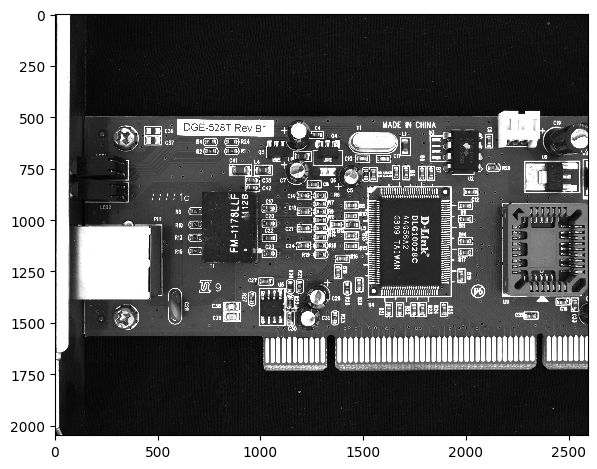

In [64]:
# Convert to GRAY to reduce number of channels
original = cv.cvtColor(cv.imread(ORIGINAL), cv.COLOR_RGB2GRAY)
imshow(original)

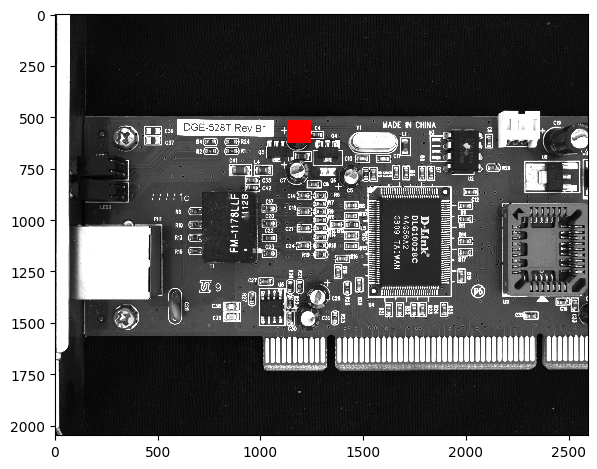

In [65]:
mask = cv.cvtColor(cv.imread(MASK), cv.COLOR_BGR2RGB)
imshow(mask)

Extract mask and masked areas to chunks

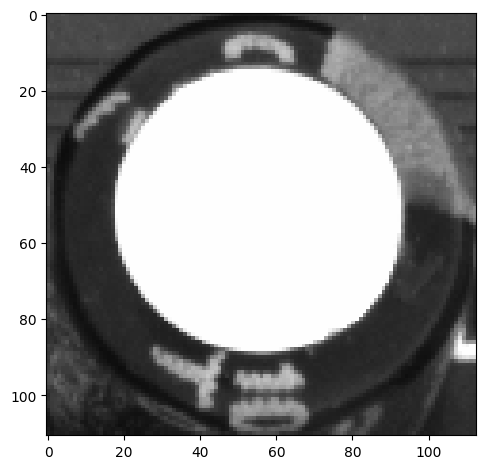

In [66]:
chunks = extract(original, MASK_COLOR, mask)
imshow(chunks[0][0])  # Image, stat_value

Generate test case - capacitor with inverse rotation

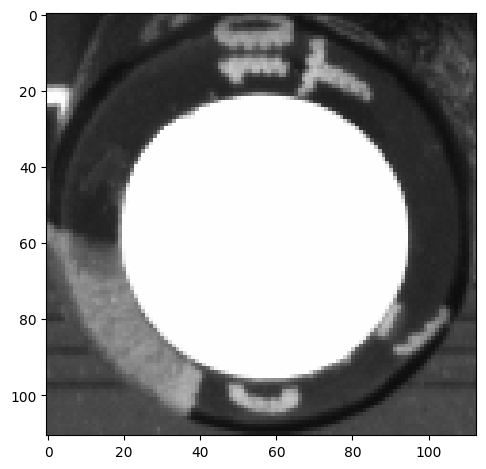

In [71]:
test_ok = chunks[0][0]
test_nok = rotate(test_ok, 180)
imshow(test_nok)

# Algorithm implementation
This part implements inspection algorithm

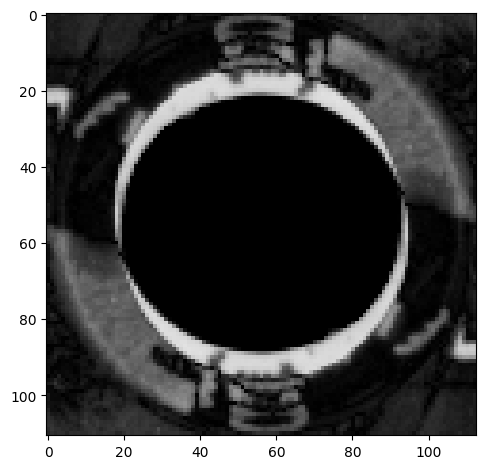

In [72]:
# difference = (test_nok/2).astype(np.uint8) + (test_ok/2).astype(np.uint8) 
difference = cv.absdiff(test_ok, test_nok)
imshow(difference)

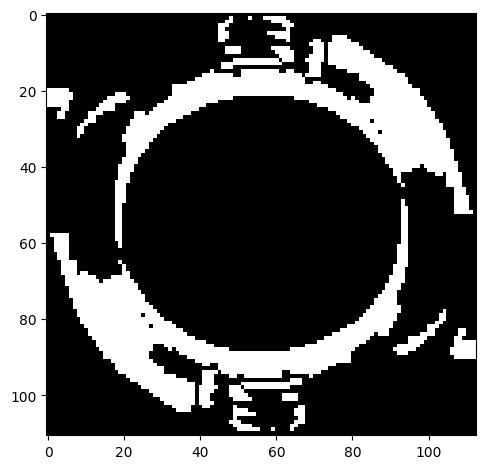

In [96]:
_, difference_threshold = cv.threshold(difference, 75, 255, cv.THRESH_BINARY)
imshow(difference_threshold)

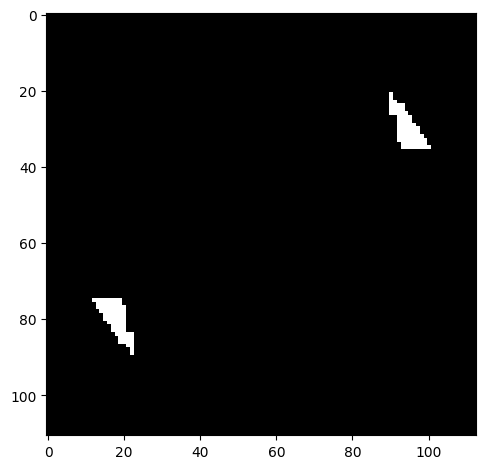

In [97]:
kernel = np.ones((5, 5), np.uint8) 
difference_erode = cv.erode(difference_threshold, kernel, iterations=2) 
imshow(difference_erode)